# Laborator 11 -> Gauss Random Partition

Se cere identificarea comunităților existente într-o rețea folosind:
- un algoritm predefinit intr-o biblioteca specializata (e.g. networkx, gephi, altele);
- un algoritm evolutiv.

Cum este creat setul de date?

nx.gaussian_random_partition_graph(n,s,v,p_in,p_out)

- n: nr de noduri
- s: media dimensiunii comunitatilor
- v: varianta (cat de mult poate varia dimensiunea unei comunitati de la media s)
- p_in: probabilitatea interna (probabilitatea ca nodurile din cadrul aceleiasi comunitati sa fie conectate printr-o muchie)
- p_out: probabilitatea externa (probabilitatea ca noduri din comunitati diferite sa fie conectate printr-o muchie)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import networkx as nx
from networkx.linalg.graphmatrix import adjacency_matrix
from pyvis.network import Network

### Vizualizarea retelei

In acest pas, scopul este sa vizualizam modul in care este organizata reteaua si sa ne facem o idee cu privire la care ar putea sa fie posibilele comunitati. Spre deosebire de retelele anterioare, aici nu vom avea un ground truth.

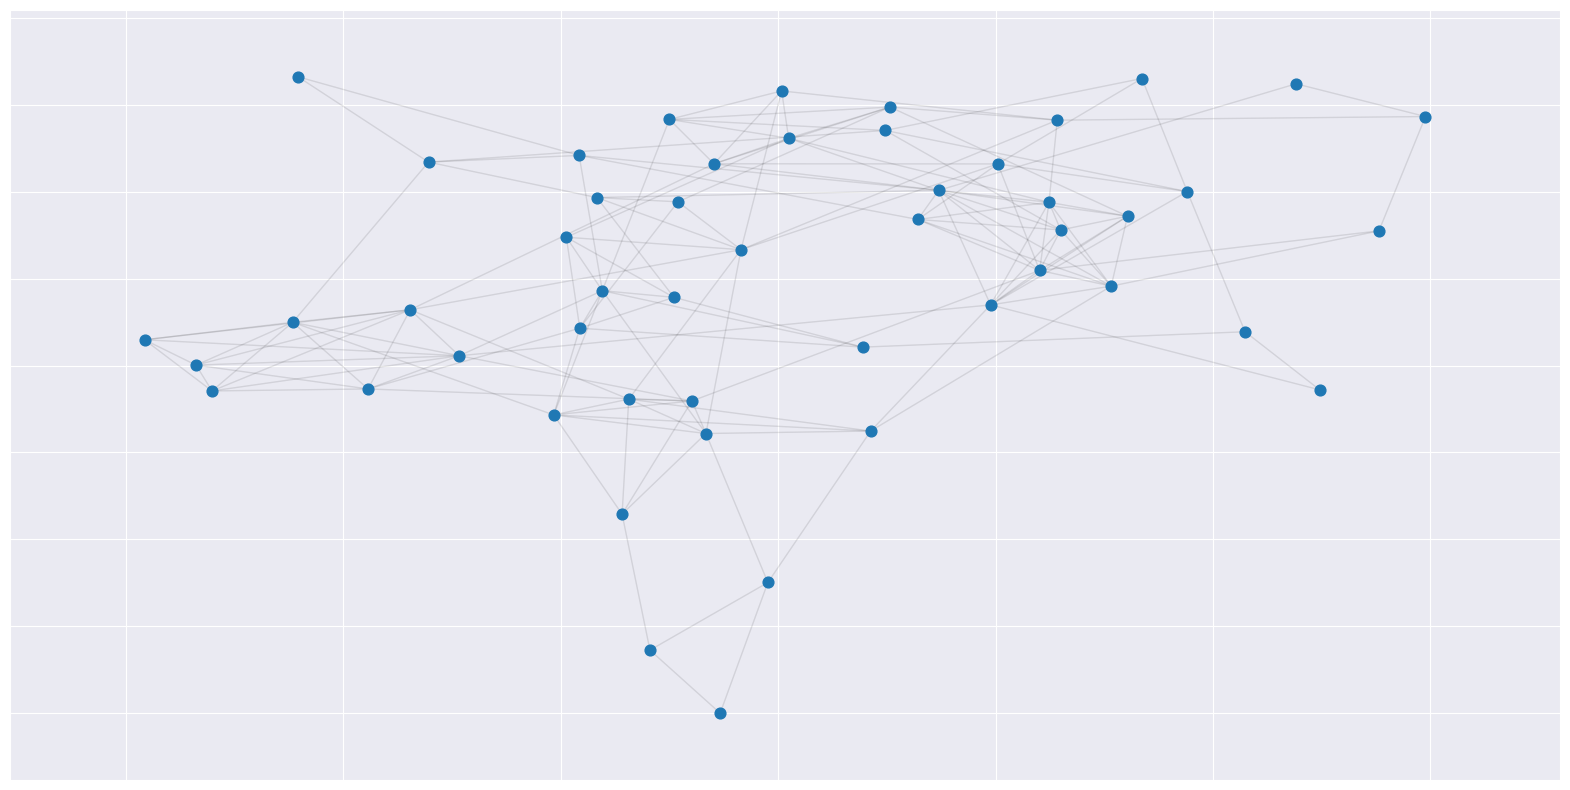

In [2]:
# graful care descrie reteaua
nrOfNodes = 50
mean = 6
variance = 4
internalProbability = 0.9
externalProbability = 0.05

G = nx.gaussian_random_partition_graph(nrOfNodes, mean, variance, internalProbability, externalProbability,seed=11)

pos = nx.spring_layout(G,seed = 11)

plt.figure(figsize=(20, 10))
nx.draw_networkx_nodes(G, pos, node_size=60)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.show(G)

### Determinarea comunitatilor cu tool

In acest pas, se foloseste algoritmul louvai din libraria networkx -> determina care sunt comunitatile.
Ulterior, se reda grafic rezultatul obtinut.

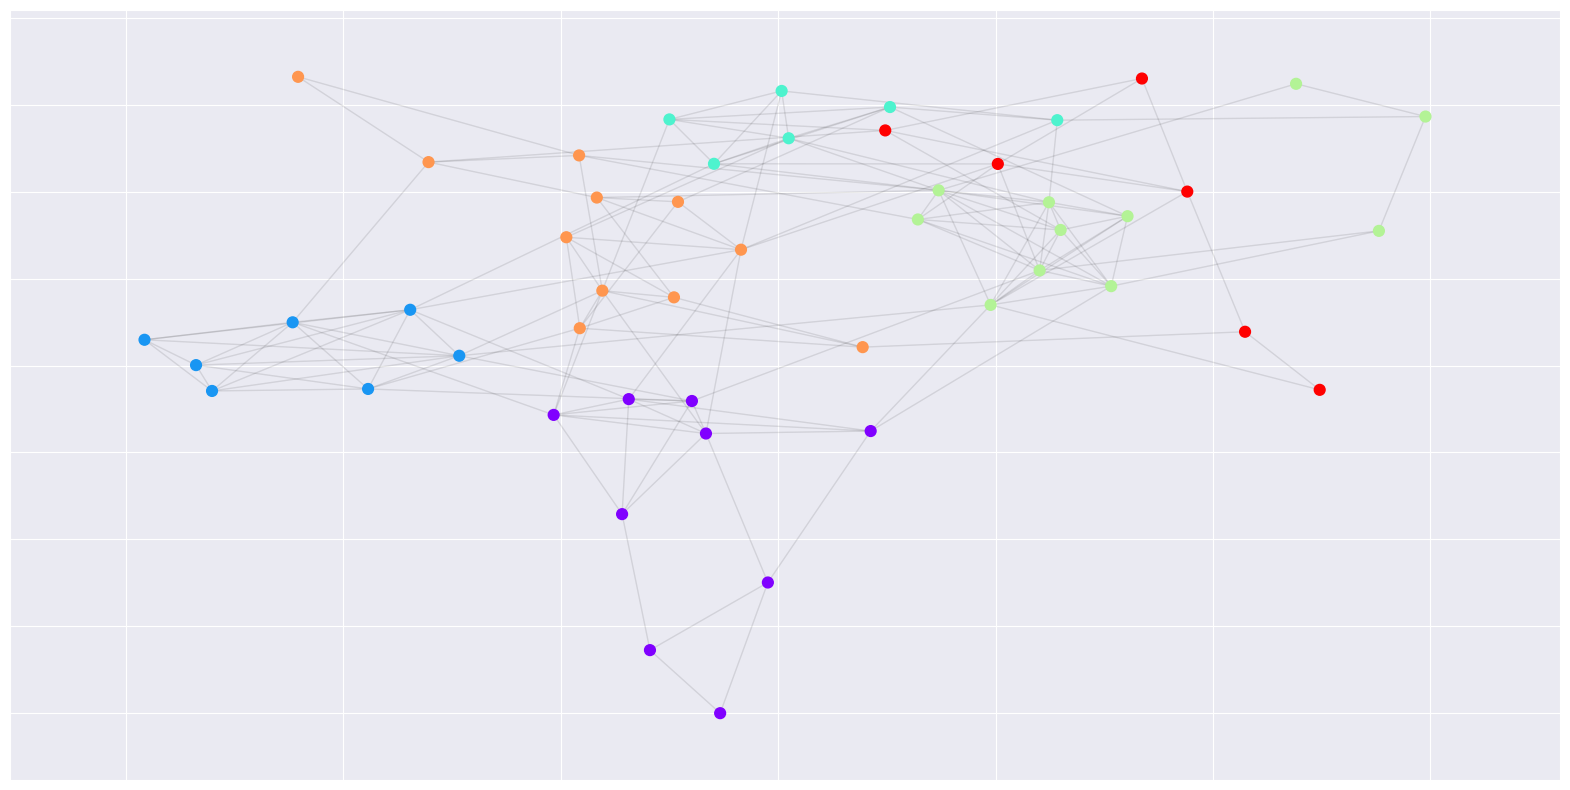

In [3]:
from networkx.algorithms import community

labelList = list(G.nodes())

# se introduce si param seed, deoarece, in cadrul algoritmului exista acea comp. aleatorie
# se vor returna seturi (comunitatile) ce contin id-urile
communityTOOL = community.louvain_communities(G, seed=11)

# reprezentarea numerica -> utila pentru evaluarea performantei
nameToId = {name: idx for idx, name in enumerate(G.nodes())}
communityTOOLNumerical = []

for nodeSet in communityTOOL:
    # se transforma fiecare nume in id-ul sau
    currentCommunity = [nameToId[nodeName] for nodeName in nodeSet]
    communityTOOLNumerical.append(currentCommunity)

communities = [0] * len(labelList)
for idComunity, com in enumerate(communityTOOLNumerical):
    for nod in com:
        #G.nodes[nod]['group'] = idComunity
        communities[nod] = idComunity


pos = nx.spring_layout(G,seed = 11)
plt.figure(figsize=(20, 10))

nx.draw_networkx_nodes(G, pos, node_size=60, cmap=plt.cm.rainbow,node_color = communities)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.show(G)

### Evaluarea performantei -> scorul de modularitate

Acest tip de evaluare a performantei algoritmului se bazeaza pe functia de fitness. Astfel, scorul de modularitate obtinut este calculat dupa urmatoarea formula: SUM(eii - ai ^2), unde:
- eii -> nr de muchii care sunt cuprinse complet in comunitatea curenta
- ai -> nr de muchii ce au minim o extremitate cuprinsa in comunitatea curenta

Interpretarea scorului:
- <= 0: algoritmul ghiceste, genereaza random comunitatile
- 0.2 - 0.6: sweet spot -> majoritatea algoritmilor o sa aiba un scor cuprins intre aceste 2 valori
- 1: impartire perfecta

In [4]:
def modularity(communities, adjacencyMatrix):
    m = sum(sum(row) for row in adjacencyMatrix) / 2
    Q = 0
    for community in communities:
        for i in community:
            for j in community:
                ki = sum(adjacencyMatrix[i])
                kj = sum(adjacencyMatrix[j])

                Q += adjacencyMatrix[i][j] - ki * kj / (2 * m)

    Q *= 1/(2*m)
    return Q

# se obtine matricea de adiacenta
adjacencyMatrix = nx.to_numpy_array(G).tolist()
print(modularity(communityTOOLNumerical, adjacencyMatrix))

0.5325333333333332


### Determinarea comunitatilor folosind cod propriu

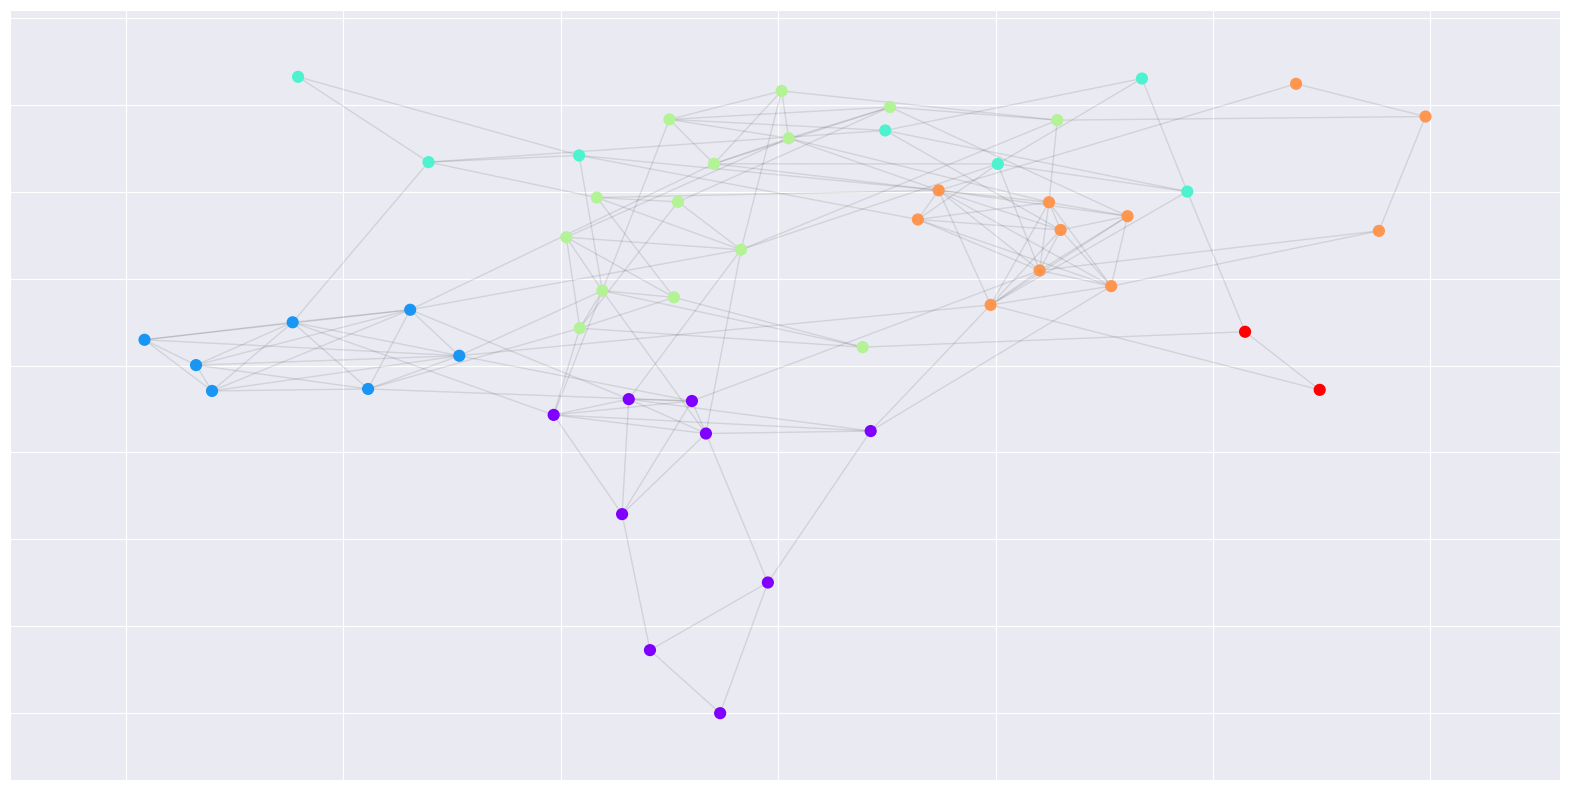

In [5]:
from fitnessModularity import fitnessFunction
import functools
from GeneticAlgorithm import GA

fitnessFunc = functools.partial(fitnessFunction, adjacencyMatrix=adjacencyMatrix)

problParam = {
    'adjacencyMatrix': adjacencyMatrix,
    'function': fitnessFunc
}

param = {
    'popSize': len(G.nodes()),
    'noGen': 500,
    'mutProb': 0.1
}

ga = GA(param=param, problParam=problParam)
best = ga.run()
decodedBest = best.decode()

communities = [0] * len(labelList)

# se seteaza noile comunitati determinate in graf
for communityId, nodesInCommunity in enumerate(decodedBest):
    for nodeIndex in nodesInCommunity:
        #nodeName = nodesList[nodeIndex]
        #G.nodes[nodeName]['group'] = communityId

        communities[nodeIndex] = communityId


pos = nx.spring_layout(G,seed = 11)
plt.figure(figsize=(20, 10))

nx.draw_networkx_nodes(G, pos, node_size=60, cmap=plt.cm.rainbow,node_color = communities)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.show(G)

### Evaluarea performantei -> scorul de modularitate

In [6]:
print(modularity(decodedBest, adjacencyMatrix))

0.5239777777777792


### Cod propriu -> Conductance Fitness Function

Se trateaza cazul in care este utilizata, drept functie de fitness, conductance. Aceasta se bazeaza pe minimizarea nr de muchii care leaga mai multe comunitati (nu fac parte dintr-o singura comunitate).

Cu ce este util?
Deteacteaza mai bine decat functia de modularitate comunitatile mici (nu are acel bias prezent la functia de modularitate cu privire la dimensiunea comunitatii).

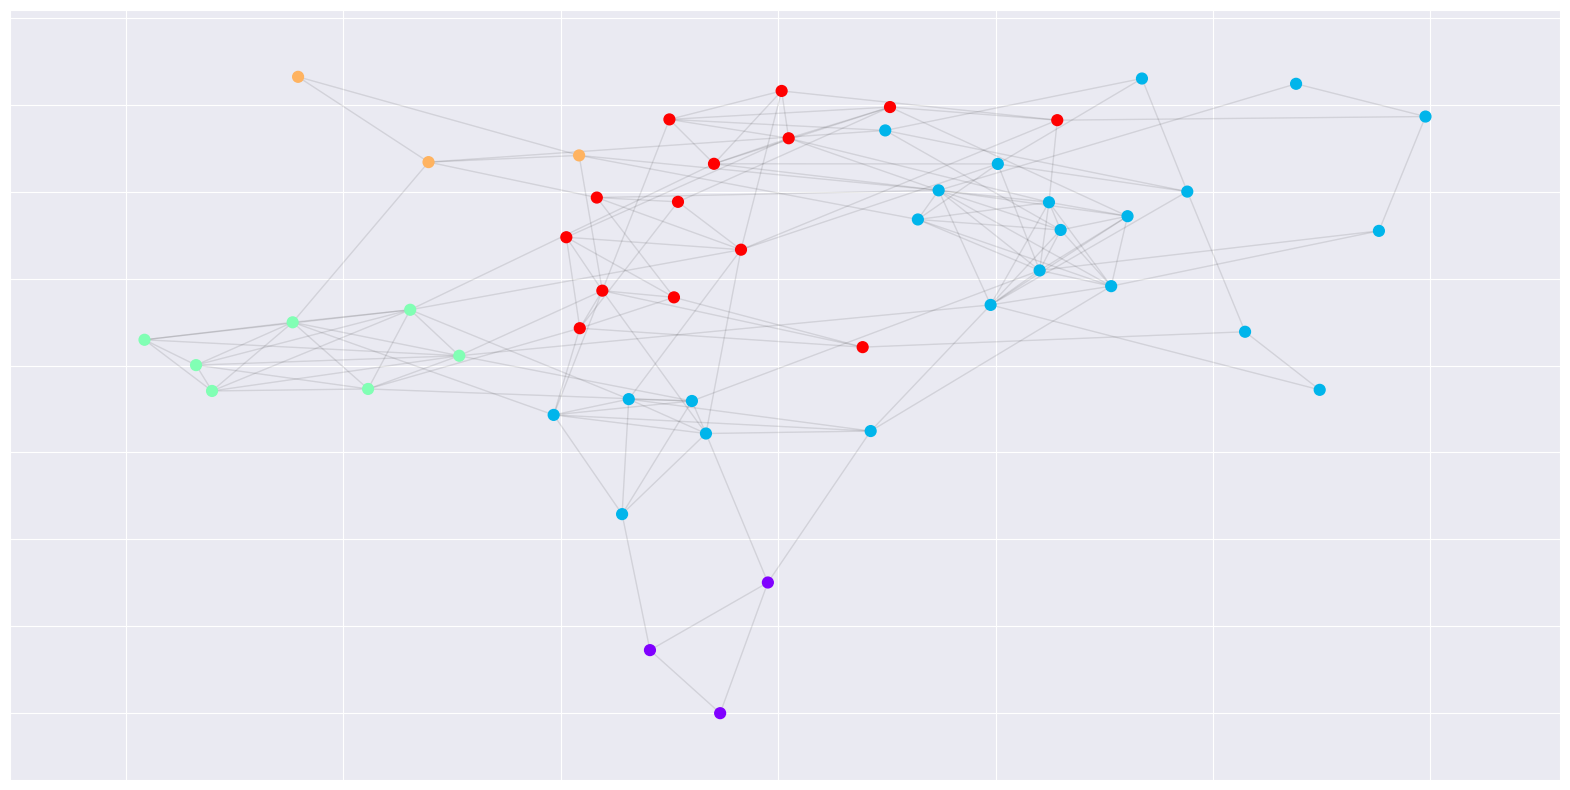

In [7]:
import fitnessConductance
import functools
from GeneticAlgorithm import GA

fitnessFunc = functools.partial(fitnessConductance.fitnessFunction, adjacencyMatrix=adjacencyMatrix)

problParam = {
    'adjacencyMatrix': adjacencyMatrix,
    'function': fitnessFunc
}

param = {
    'popSize': len(G.nodes()),
    'noGen': 500,
    'mutProb': 0.1
}

ga = GA(param=param, problParam=problParam)
best = ga.run()
decodedBest = best.decode()

communities = [0] * len(labelList)

# se seteaza noile comunitati determinate in graf
for communityId, nodesInCommunity in enumerate(decodedBest):
    for nodeIndex in nodesInCommunity:
        #nodeName = nodesList[nodeIndex]
        #G.nodes[nodeName]['group'] = communityId

        communities[nodeIndex] = communityId


pos = nx.spring_layout(G,seed = 11)
plt.figure(figsize=(20, 10))

nx.draw_networkx_nodes(G, pos, node_size=60, cmap=plt.cm.rainbow,node_color = communities)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.show(G)

### Evaluarea performantei pt Conductance

Cum se interpreteaza rezultatul:
- 0: comunitate perfecta
- <= 0.3: good communities
- <= 0.6: weak communities
- 1: poor partition

In [8]:
def conductance(communities, adjacencyMatrix):
    # CONDUCTANCE: 1/k * sum(c(i))
    # c(i) = cut(c,c_)/min(vol(c),vol(c_))
    # vol(c) -> suma tuturor gradelor nodurilor din interiorul comunitatii

    Q = 0

    overallSum = 0
    for community in communities:
        for node in community:
            overallSum += sum(adjacencyMatrix[node])

    for community in communities:
        outsiders = 0
        summ = 0
        for i in community:
            for neighbour,value in enumerate(adjacencyMatrix[i]):
                if value != 0:
                    if neighbour not in community:
                        outsiders += 1
                    summ += 1

        if min(summ, overallSum - summ) == 0:
            continue

        Q+= outsiders/ min(summ,overallSum - summ)

    Q /= len(communities)
    return Q

print(conductance(decodedBest, adjacencyMatrix))

0.29628899835796385
